# 04. Оценка и анализ ошибок

**Цель:** оценить выбранную модель на test и найти слабые сегменты.
**Условия:** F1-порог выбран на отдельном периоде. Test не используется для подбора; scores не считаются откалиброванными вероятностями.

[Итоговый отчёт](../reports/full/RESULTS.md)

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import joblib
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "pyproject.toml").exists() and (p / "notebooks").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Запустите notebook из корня проекта или notebooks")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from aml.workflow import (load_split, ranking_metrics, resolve_run, resolve_training,
    new_run, load_raw, temporal_slices, error_summary)
from sklearn.metrics import (precision_recall_curve, precision_score, recall_score,
    f1_score, confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
RUN_DIR = resolve_run(PROJECT_ROOT)
DATA_DIR = RUN_DIR / "data"
TRAIN_DIR = resolve_training(RUN_DIR)
EVAL_DIR = new_run(TRAIN_DIR, "evaluations")
bundle = joblib.load(TRAIN_DIR / "champion.joblib")
manifest = json.loads((RUN_DIR / "data_manifest.json").read_text())
if bundle["run_id"] != manifest["run_id"]:
    raise ValueError("Данные пересобраны: повторите 03")

In [2]:
X_threshold, y_threshold = load_split("threshold", DATA_DIR)
if list(X_threshold.columns) != bundle["features"] or y_threshold.nunique() != 2:
    raise ValueError("Invalid threshold split")
threshold_scores = bundle["model"].predict_proba(X_threshold)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_threshold, threshold_scores)
f1 = np.divide(2*precision[:-1]*recall[:-1], precision[:-1]+recall[:-1],
               out=np.zeros_like(precision[:-1]), where=(precision[:-1]+recall[:-1]) > 0)
threshold = float(thresholds[np.argmax(f1)])
(EVAL_DIR / "threshold.json").write_text(json.dumps({"threshold": threshold, "run_id": bundle["run_id"], "policy": "max F1 on threshold period"}))
print("Frozen threshold:", threshold)

Frozen threshold: 0.2987750172615051


In [3]:
X_test, y_test = load_split("test", DATA_DIR)
if list(X_test.columns) != bundle["features"]:
    raise ValueError("Test schema mismatch")
scores = bundle["model"].predict_proba(X_test)[:, 1]
predicted = scores >= threshold
metrics = {**ranking_metrics(y_test, scores),
           "precision": precision_score(y_test, predicted, zero_division=0),
           "recall": recall_score(y_test, predicted, zero_division=0),
           "F1": f1_score(y_test, predicted, zero_division=0),
           "alert_rate": float(predicted.mean()), "prevalence": float(y_test.mean()),
           "Brier": brier_score_loss(y_test, scores)}
display(pd.Series(metrics, name=bundle["name"]))
display(pd.DataFrame(confusion_matrix(y_test, predicted, labels=[0,1]), index=["actual 0", "actual 1"], columns=["pred 0", "pred 1"]))
pd.Series(metrics).to_csv(EVAL_DIR / "test_metrics.csv")

AP            0.373919
ROC-AUC       0.962133
precision     0.676056
recall        0.319574
F1            0.433996
alert_rate    0.000342
prevalence    0.000723
Brier         0.000571
Name: XGBoost, dtype: float64

,pred 0,pred 1
actual 0,1038236,115
actual 1,511,240


## Ранжирование и калибровка

PR-кривая описывает ранжирование; calibration curve — диагностика без коррекции scores.

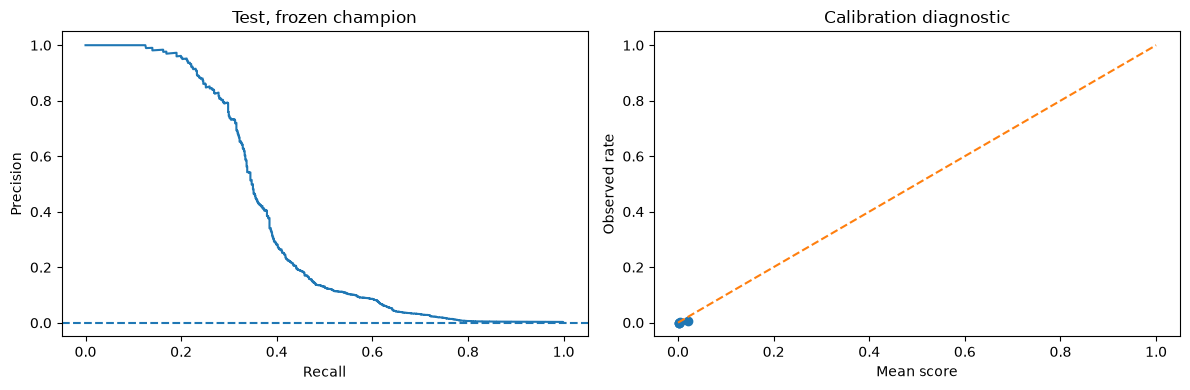

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p, r, _ = precision_recall_curve(y_test, scores)
axes[0].plot(r, p); axes[0].axhline(y_test.mean(), linestyle="--")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Test, frozen champion")
if y_test.nunique() == 2:
    observed, predicted_mean = calibration_curve(y_test, scores, n_bins=10, strategy="quantile")
    axes[1].plot(predicted_mean, observed, "o-")
axes[1].plot([0,1],[0,1], "--")
axes[1].set(xlabel="Mean score", ylabel="Observed rate", title="Calibration diagnostic")
plt.tight_layout(); plt.show()

## Ошибки по сегментам

Новый счёт отсутствовал в train в обеих ролях. NaN означает отсутствие знаменателя для метрики; малые группы интерпретируются осторожно.

In [5]:
raw = load_raw(PROJECT_ROOT)
periods = temporal_slices(raw["Timestamp"])
raw_train = raw.iloc[periods["train"]]
raw_test = raw.iloc[periods["test"]].reset_index(drop=True)
stored_time = pd.read_parquet(DATA_DIR / "test_time.parquet")["Timestamp"]
if (len(raw_test) != len(y_test) or
    not raw_test["Timestamp"].equals(stored_time.reset_index(drop=True)) or
    not np.array_equal(raw_test["Is Laundering"], y_test)):
    raise ValueError("Raw source does not match saved test")
for amount in ["Amount Paid", "Amount Received"]:
    if not np.array_equal(raw_test[amount], X_test[amount]):
        raise ValueError("Raw amounts differ from saved features")
known = pd.MultiIndex.from_frame(pd.concat([
    raw_train[["From Bank", "Account"]].set_axis(["bank", "account"], axis=1),
    raw_train[["To Bank", "Account.1"]].set_axis(["bank", "account"], axis=1)
], ignore_index=True)).unique()
segments = raw_test[["Payment Currency", "Payment Format"]].copy()
segments["day"] = raw_test["Timestamp"].dt.floor("D")
segments["hour"] = raw_test["Timestamp"].dt.hour
for role, columns in {"sender": ["From Bank", "Account"], "receiver": ["To Bank", "Account.1"]}.items():
    segments[role + "_status"] = np.where(pd.MultiIndex.from_frame(raw_test[columns]).isin(known), "known_in_train", "new_to_train")
segments["target"] = y_test.to_numpy()
segments["prediction"] = predicted
segment_reports = {}
for column in ["Payment Currency", "Payment Format", "day", "hour", "sender_status", "receiver_status"]:
    table = pd.DataFrame({str(name): error_summary(group) for name, group in segments.groupby(column, observed=True)}).T
    table.index.name = column
    table = table.sort_values("FN", ascending=False)
    table.to_csv(EVAL_DIR / (column.replace(" ", "_") + "_errors.csv"))
    segment_reports[column] = table
    display(table)
print("Saved diagnostic tables:", EVAL_DIR.relative_to(PROJECT_ROOT))


,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
Payment Currency,,,,,,,,,
US Dollar,383900.0,335.0,127.0,55.0,208.0,182.0,0.697802,0.379104,0.000474
Euro,238437.0,231.0,96.0,39.0,135.0,135.0,0.711111,0.415584,0.000566
Yuan,72500.0,36.0,5.0,5.0,31.0,10.0,0.500000,0.138889,0.000138
Rupee,51690.0,29.0,2.0,4.0,27.0,6.0,0.333333,0.068966,0.000116
Bitcoin,45764.0,18.0,0.0,0.0,18.0,0.0,NaN,0.000000,0.000000
Saudi Riyal,38825.0,18.0,1.0,1.0,17.0,2.0,0.500000,0.055556,0.000052
Brazil Real,29855.0,15.0,1.0,1.0,14.0,2.0,0.500000,0.066667,0.000067
Canadian Dollar,26701.0,14.0,1.0,2.0,13.0,3.0,0.333333,0.071429,0.000112
Shekel,26179.0,9.0,0.0,0.0,9.0,0.0,NaN,0.000000,0.000000


,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
Payment Format,,,,,,,,,
ACH,141726.0,596.0,240.0,115.0,356.0,355.0,0.676056,0.402685,0.002505
Cheque,418314.0,80.0,0.0,0.0,80.0,0.0,NaN,0.000000,0.000000
Credit Card,287206.0,42.0,0.0,0.0,42.0,0.0,NaN,0.000000,0.000000
Bitcoin,45765.0,18.0,0.0,0.0,18.0,0.0,NaN,0.000000,0.000000
Cash,109982.0,15.0,0.0,0.0,15.0,0.0,NaN,0.000000,0.000000
Wire,36109.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.000000


,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
day,,,,,,,,,
2022-09-09 00:00:00,756002.0,316.0,70.0,49.0,246.0,119.0,0.588235,0.221519,0.000157
2022-09-10 00:00:00,282877.0,301.0,75.0,56.0,226.0,131.0,0.572519,0.249169,0.000463
2022-09-11 00:00:00,77.0,47.0,36.0,3.0,11.0,39.0,0.923077,0.765957,0.506494
2022-09-13 00:00:00,48.0,29.0,18.0,1.0,11.0,19.0,0.947368,0.620690,0.395833
2022-09-12 00:00:00,48.0,27.0,19.0,5.0,8.0,24.0,0.791667,0.703704,0.500000
2022-09-14 00:00:00,31.0,18.0,12.0,1.0,6.0,13.0,0.923077,0.666667,0.419355
2022-09-15 00:00:00,9.0,6.0,4.0,0.0,2.0,4.0,1.000000,0.666667,0.444444
2022-09-16 00:00:00,7.0,5.0,4.0,0.0,1.0,4.0,1.000000,0.800000,0.571429
2022-09-17 00:00:00,3.0,2.0,2.0,0.0,0.0,2.0,1.000000,1.000000,0.666667


,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
hour,,,,,,,,,
3,39992.0,37.0,4.0,4.0,33.0,8.0,0.500000,0.108108,0.000200
16,47408.0,46.0,16.0,9.0,30.0,25.0,0.640000,0.347826,0.000527
20,47436.0,36.0,9.0,9.0,27.0,18.0,0.500000,0.250000,0.000379
11,47223.0,48.0,21.0,6.0,27.0,27.0,0.777778,0.437500,0.000572
8,46587.0,38.0,11.0,4.0,27.0,15.0,0.733333,0.289474,0.000322
21,46956.0,32.0,6.0,5.0,26.0,11.0,0.545455,0.187500,0.000234
9,47105.0,35.0,9.0,6.0,26.0,15.0,0.600000,0.257143,0.000318
19,47893.0,38.0,12.0,4.0,26.0,16.0,0.750000,0.315789,0.000334
13,47487.0,47.0,21.0,12.0,26.0,33.0,0.636364,0.446809,0.000695


,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
sender_status,,,,,,,,,
known_in_train,1037890.0,731.0,234.0,114.0,497.0,348.0,0.672414,0.320109,0.000335
new_to_train,1212.0,20.0,6.0,1.0,14.0,7.0,0.857143,0.300000,0.005776


,rows,positives,TP,FP,FN,alerts,precision,recall,alert_rate
receiver_status,,,,,,,,,
known_in_train,1037932.0,739.0,239.0,115.0,500.0,354.0,0.675141,0.323410,0.000341
new_to_train,1170.0,12.0,1.0,0.0,11.0,1.0,1.000000,0.083333,0.000855


Saved diagnostic tables: artifacts/runs/full/evaluations/20260908T182247Z_168f8da8a4c1


## Выводы

- Test AP — 0,3739; precision — 67,61%, recall — 31,96%. Найдены 240 из 751 положительной транзакции.
- Все 355 алертов относятся к ACH; вне ACH пропущены все 155 положительных.
- У новых получателей найден 1 из 12 положительных — группа мала. Новая модель или порог требуют нового holdout.